# BigBird: Transformers for Longer Sequences
### Architecture, motivation, sparse attention, complexity, and applications

**Paper:** Zaheer et al., *Big Bird: Transformers for Longer Sequences*, Google Research, NeurIPS 2020 ([arXiv:2007.14062](https://arxiv.org/abs/2007.14062))
**Code / checkpoints:** [google-research/bigbird](https://github.com/google-research/bigbird), Hugging Face `google/bigbird-roberta-base`, `google/bigbird-pegasus-large-arxiv`

## Contents
1. Motivation: the quadratic bottleneck
2. BigBird in one picture: three attention patterns
3. Block-sparse implementation (what actually runs on GPU/TPU)
4. Why it works: graph theory + theory results
5. Complexity: BERT vs Longformer vs BigBird (with plots)
6. Using BigBird (Hugging Face)
7. Applications for long documents
8. Performance characteristics
9. Advantages, limitations, when to choose what
10. Quick-reference cheat sheet
11. References

## 1. Motivation: the quadratic bottleneck

Standard (full) self-attention computes, for a sequence of length $n$ and head dimension $d$:

$$\text{Attention}(Q,K,V)=\text{softmax}\!\left(\frac{QK^\top}{\sqrt d}\right)V,\qquad QK^\top\in\mathbb R^{n\times n}$$

| Resource | Full attention |
|---|---|
| Time (FLOPs) | $O(n^2 d)$ |
| Memory for the score matrix | $O(n^2)$ per head, per layer |

The BigBird paper identifies the **quadratic dependency (mainly in memory)** on sequence length as the core limitation, and notes that on commonly available hardware it translates into a practical limit of roughly **512 tokens** for BERT-style models.

**Consequences for long documents**
- Truncation loses information (answer may be past token 512).
- Chunking/sliding windows break cross-chunk dependencies (multi-hop QA, coreference, long-range discourse).
- Pipelines become complex (retrieve, chunk, merge) and error-prone.

**BigBird's goal:** replace full attention with a *sparse* mechanism that is linear in $n$, while keeping the theoretical properties that make Transformers powerful (universal approximation, Turing completeness).

**Headline claims (abstract):** sparse attention reduces the quadratic dependency to linear; BigBird is a universal approximator of sequence functions and Turing complete; it handles sequences up to **8x longer** on similar hardware; improves QA and summarization; and is applied to genomics.

## 2. The three ingredients of BigBird attention

BigBird views attention as a **directed graph** over tokens: an edge $i\to j$ means token $i$ may attend to token $j$. Full attention is the complete graph. BigBird uses a sparse graph built from three components:

| Component | Idea | Role |
|---|---|---|
| **Sliding window** (local) | each token attends to $w$ neighbours | Language is local; captures nearby syntax/semantics |
| **Global tokens** | $g$ tokens attend to everything and everything attends to them | Information hubs; shortcuts across the whole sequence |
| **Random attention** | each query attends to $r$ random keys | Creates shortcuts; makes the graph an expander / small-world network |

Two global-token variants are defined in the paper:
- **ITC (Internal Transformer Construction):** some *existing* tokens (e.g. `[CLS]`, first tokens) are made global.
- **ETC (Extended Transformer Construction):** *extra* global tokens are **added** to the sequence (e.g. summary tokens), as in Ainslie et al.'s ETC.

Let's build and visualise a **token-level** version first (conceptually simple).

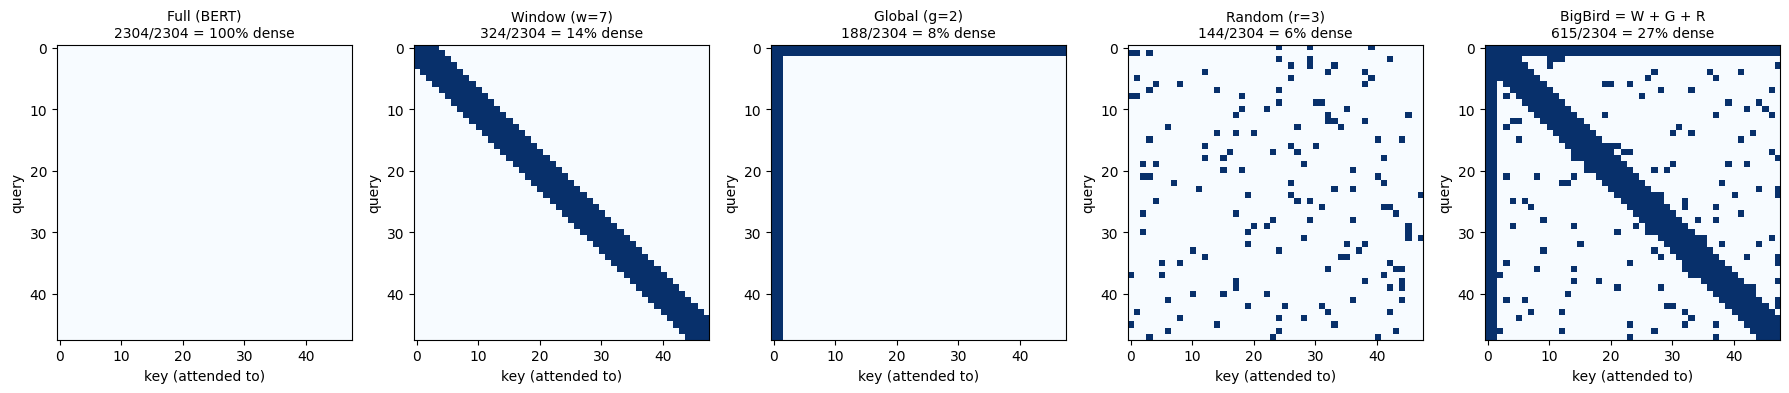

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

rng = np.random.default_rng(0)

def full_mask(n):
    return np.ones((n, n), dtype=bool)

def window_mask(n, w):
    # each token attends to w//2 tokens on each side (and itself)
    m = np.zeros((n, n), dtype=bool)
    half = w // 2
    for i in range(n):
        m[i, max(0, i - half): min(n, i + half + 1)] = True
    return m

def global_mask(n, g):
    # first g tokens are global (ITC style): they attend to all, all attend to them
    m = np.zeros((n, n), dtype=bool)
    m[:g, :] = True
    m[:, :g] = True
    return m

def random_mask(n, r, rng=rng):
    # each query attends to r random keys
    m = np.zeros((n, n), dtype=bool)
    for i in range(n):
        m[i, rng.choice(n, size=r, replace=False)] = True
    return m

def bigbird_token_mask(n, w=7, g=2, r=3, rng=rng):
    return window_mask(n, w) | global_mask(n, g) | random_mask(n, r, rng)

n = 48
panels = {
    "Full (BERT)": full_mask(n),
    "Window (w=7)": window_mask(n, 7),
    "Global (g=2)": global_mask(n, 2),
    "Random (r=3)": random_mask(n, 3),
    "BigBird = W + G + R": bigbird_token_mask(n, 7, 2, 3),
}
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
for ax, (name, m) in zip(axes, panels.items()):
    ax.imshow(m, cmap="Blues", interpolation="nearest")
    ax.set_title(f"{name}\n{m.sum()}/{n*n} = {m.mean():.0%} dense", fontsize=10)
    ax.set_xlabel("key (attended to)"); ax.set_ylabel("query")
plt.tight_layout(); plt.show()

## 3. Block-sparse implementation (what actually runs on accelerators)

A token-level random pattern is **inefficient on GPU/TPU**: gathering scattered individual elements wastes memory bandwidth and cannot use dense matrix-multiply units well. The paper's solution is to **pack the sequence into blocks** and apply the sparse pattern at *block* granularity, so every operation becomes a small dense matmul.

**Procedure**
1. Split the sequence of length $n$ into $n/b$ blocks of size $b$ (e.g. $b=64$).
2. Treat each block as a "super-node". Pattern is defined over blocks:
   - **Window:** query block $i$ attends to key blocks $i-1, i, i+1$ (3 blocks)
   - **Global:** first and last blocks are global (2 blocks) *(Hugging Face ITC default)*
   - **Random:** each query block attends to $r$ random key blocks (e.g. $r=3$)
3. Compute attention using dense block-matmuls on gathered blocks.

**Per query token this means attending to** $(3 + 2 + r)\cdot b$ keys. With the Hugging Face defaults ($b=64$, $r=3$): $(3+2+3)\times 64 = \mathbf{512}$ keys, i.e. the *same* per-token cost as full BERT attention at length 512, but at sequence length 4096 (8x longer, matching the paper's "8x" claim).

Hugging Face defaults: `attention_type="block_sparse"`, `block_size=64`, `num_random_blocks=3`, max length 4096. Note that if the sequence is short, HF automatically falls back to full attention (`original_full`) because block-sparse has no benefit there.

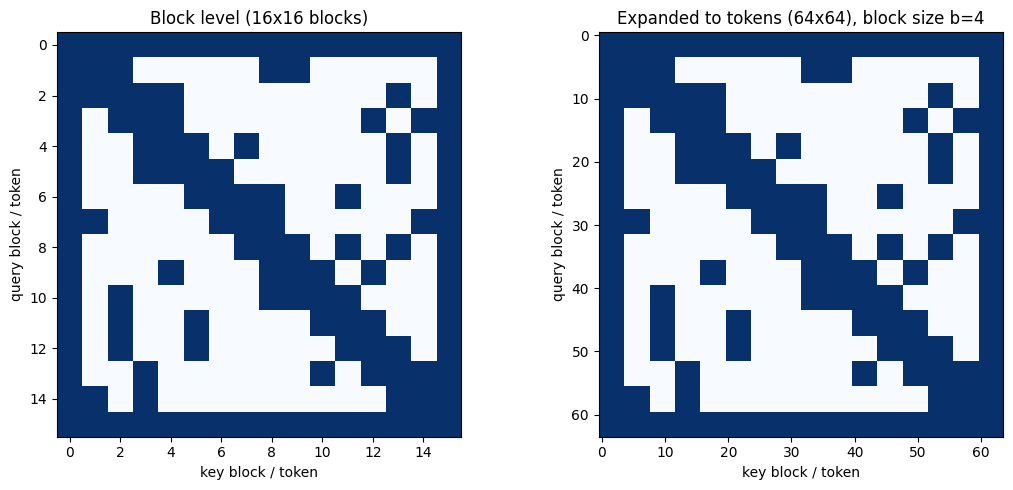

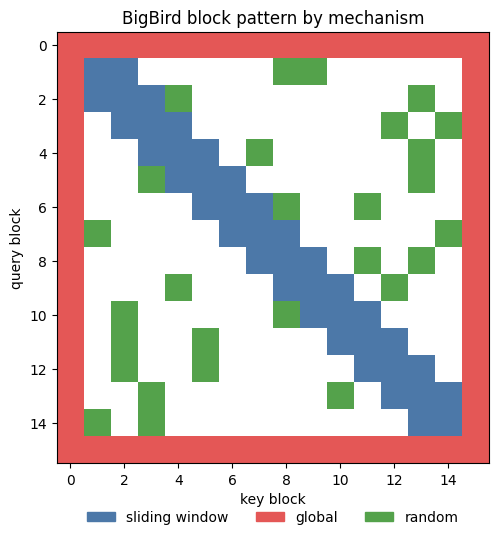

Keys per query token (HF defaults): 512


In [2]:
def bigbird_block_mask(n_blocks, window=3, n_global=2, n_random=3, rng=None, seed=1):
    # Block-level BigBird mask (ITC-style): first/last block global.
    rng = rng or np.random.default_rng(seed)
    m = np.zeros((n_blocks, n_blocks), dtype=bool)
    half = window // 2
    for i in range(n_blocks):
        m[i, max(0, i - half): min(n_blocks, i + half + 1)] = True        # sliding window
    g_idx = [0, n_blocks - 1][:n_global]
    m[g_idx, :] = True                                                      # global rows
    m[:, g_idx] = True                                                      # global cols
    for i in range(n_blocks):                                               # random blocks
        if i in g_idx:
            continue
        candidates = [j for j in range(n_blocks) if not m[i, j]]
        pick = rng.choice(candidates, size=min(n_random, len(candidates)), replace=False)
        m[i, pick] = True
    return m

def block_to_token(m_block, b):
    return np.kron(m_block, np.ones((b, b), dtype=bool))

nb_, b = 16, 4         # 16 blocks x block size 4 => 64 tokens (toy)
mb = bigbird_block_mask(nb_, window=3, n_global=2, n_random=2)
mt = block_to_token(mb, b)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(mb, cmap="Blues"); ax[0].set_title(f"Block level ({nb_}x{nb_} blocks)")
ax[1].imshow(mt, cmap="Blues"); ax[1].set_title(f"Expanded to tokens ({nb_*b}x{nb_*b}), block size b={b}")
for a in ax: a.set_xlabel("key block / token"); a.set_ylabel("query block / token")
plt.tight_layout(); plt.show()

# Colour-coded version: which mechanism produced each block?
def labelled_block_mask(n_blocks, n_random=2, seed=1):
    rng = np.random.default_rng(seed)
    lab = np.zeros((n_blocks, n_blocks), dtype=int)   # 0 none, 1 window, 2 global, 3 random
    for i in range(n_blocks):
        for j in (i - 1, i, i + 1):
            if 0 <= j < n_blocks: lab[i, j] = 1
    for g in (0, n_blocks - 1):
        lab[g, :] = 2; lab[:, g] = 2
    for i in range(1, n_blocks - 1):
        free = [j for j in range(n_blocks) if lab[i, j] == 0]
        lab[i, rng.choice(free, size=n_random, replace=False)] = 3
    return lab

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
lab = labelled_block_mask(16)
cmap = ListedColormap(["white", "#4C78A8", "#E45756", "#54A24B"])
plt.figure(figsize=(5.5, 5.5))
plt.imshow(lab, cmap=cmap, vmin=0, vmax=3)
plt.legend(handles=[Patch(color="#4C78A8", label="sliding window"),
                    Patch(color="#E45756", label="global"),
                    Patch(color="#54A24B", label="random")],
           loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.title("BigBird block pattern by mechanism"); plt.xlabel("key block"); plt.ylabel("query block")
plt.tight_layout(); plt.show()

# Keys per query token with the Hugging Face defaults
b_hf, r_hf = 64, 3
print("Keys per query token (HF defaults):", (3 + 2 + r_hf) * b_hf)

## 4. Why sparse attention can still work

### 4.1 Graph-theoretic intuition
Each layer lets information move along graph edges. To model long-range dependencies, **any two tokens should be reachable in few hops**.

| Pattern | Path length between far tokens | Comment |
|---|---|---|
| Window only | $\approx n/w$ hops | Needs many layers; long-range info is slow |
| Window + **random** | $\approx O(\log n)$ hops | Random edges make the graph an **expander / small-world** network |
| Window + random + **global** | $\le 2$ hops via a global token | Hubs give an immediate shortcut |

The demo below measures this empirically.

In [3]:
def to_adj(mask):
    # treat attention as undirected for reachability intuition (info can flow either way across layers)
    sym = mask | mask.T
    np.fill_diagonal(sym, False)
    return [np.flatnonzero(sym[i]).tolist() for i in range(len(sym))]

def bfs_dists(adj, s):
    d = [-1] * len(adj); d[s] = 0; q = deque([s])
    while q:
        u = q.popleft()
        for v in adj[u]:
            if d[v] < 0:
                d[v] = d[u] + 1; q.append(v)
    return d

def avg_and_max_path(mask, samples=40, seed=0):
    adj = to_adj(mask); r = np.random.default_rng(seed)
    srcs = r.choice(len(adj), size=min(samples, len(adj)), replace=False)
    allp = []
    for s in srcs:
        d = np.array(bfs_dists(adj, s)); allp.append(d[d > 0])
    allp = np.concatenate(allp)
    return allp.mean(), allp.max()

n = 512
configs = {
    "Window only (w=7)":               window_mask(n, 7),
    "Window + Random (r=2)":           window_mask(n, 7) | random_mask(n, 2, np.random.default_rng(1)),
    "Window + Global (g=2)":           window_mask(n, 7) | global_mask(n, 2),
    "Window + Random + Global (BigBird)": bigbird_token_mask(n, 7, 2, 2, np.random.default_rng(1)),
    "Full attention":                   full_mask(n),
}
print(f"{'Pattern':40s} {'avg hops':>9s} {'max hops':>9s}   density")
for name, m in configs.items():
    a, mx = avg_and_max_path(m)
    print(f"{name:40s} {a:9.2f} {mx:9d}   {m.mean():.1%}")

Pattern                                   avg hops  max hops   density
Window only (w=7)                            57.52       170   1.4%
Window + Random (r=2)                         3.19         5   1.7%
Window + Global (g=2)                         1.96         2   2.1%
Window + Random + Global (BigBird)            1.95         2   2.5%


Full attention                                1.00         1   100.0%


**Reading the output:** window-only needs *dozens* of hops to cross the sequence; adding just a couple of random edges per token collapses that to a handful (logarithmic scaling); adding global tokens bounds it at ~2. Full attention is 1 hop but costs $n^2$.

### 4.2 Theoretical guarantees (from the paper)
- **Universal approximation:** sparse BigBird (with global tokens) can approximate any continuous sequence-to-sequence function on a compact domain, as full attention can.
- **Turing completeness:** BigBird is Turing complete (under the standard idealised assumptions used for Transformers).
- **Role of global tokens:** theory shows $O(1)$ global tokens (e.g. `[CLS]`) matter; the paper also gives a *limitation*: there exist tasks that full attention solves in $O(1)$ layers but sparse attention needs $\Omega(n)$ layers (e.g. finding the furthest vector from each query). Sparse is not free.

### 4.3 Practical remark: BigBird as a drop-in
BigBird keeps the BERT/RoBERTa-style encoder (post-norm) or Pegasus-style encoder-decoder (pre-norm). Only the **attention pattern** changes, so BERT/RoBERTa weights can initialise it (the released base model is warm-started from RoBERTa and then pretrained on long sequences with MLM).

## 5. Complexity: BERT vs Longformer vs BigBird

| Model | Attention pattern | Time / memory (attention) | Typical max length |
|---|---|---|---|
| **BERT** | Full | $O(n^2)$ | 512 |
| **Longformer** | Sliding window ($w$) + task-specific global ($g$) (+ optional dilation) | $O(n\cdot w + n\cdot g)$ ≈ $O(n)$ | 4096 |
| **BigBird** | Block window + global + **random** | $O(n\cdot(w + g + r)\cdot b)$ ≈ $O(n)$ | 4096 (paper experiments) |

Notes:
- Both Longformer and BigBird are **linear** in $n$ for fixed $w, g, r, b$. The constants differ.
- Longformer's global tokens are chosen **per task** (e.g. question tokens in QA, `[CLS]` in classification) and must be set by the user; BigBird's default pattern (ITC) uses fixed global blocks, ETC adds extra global tokens.
- BigBird's distinguishing feature is **random attention**, which gives provable connectivity/expressivity properties. Longformer lacks it.
- Linear attention *scaling* does not mean linear *wall-clock* at short lengths. Below roughly the pattern size (~1k tokens) full attention is often as fast or faster, which is why HF falls back to full attention for short inputs.

Let's quantify the number of attention-matrix entries (proportional to FLOPs and attention memory).

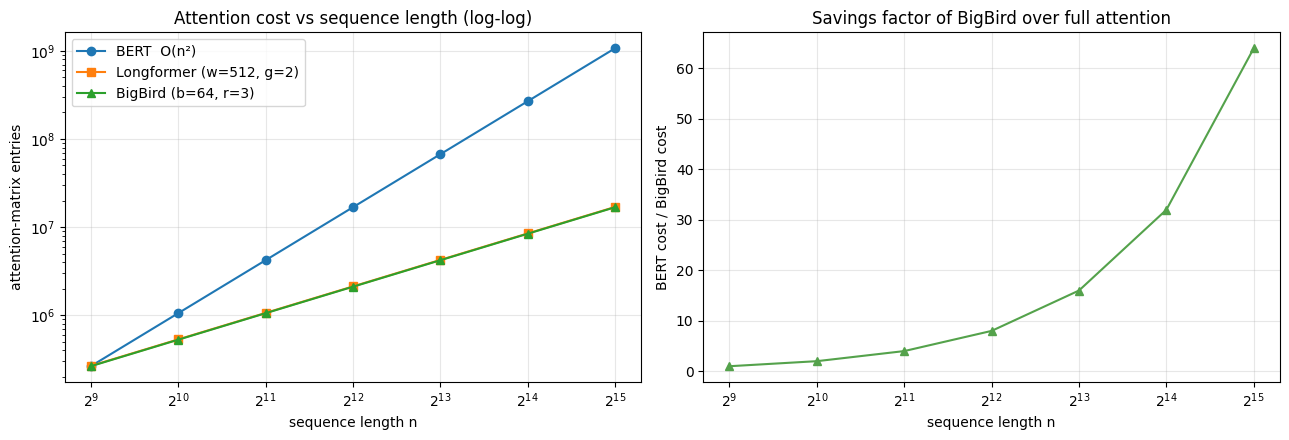

      n    BERT (MB)  Longformer (MB)  BigBird (MB)
    512          0.5              0.5           0.5
   1024          2.1              1.1           1.0
   2048          8.4              2.1           2.1
   4096         33.6              4.2           4.2
   8192        134.2              8.5           8.4
  16384        536.9             16.9          16.8
  32768       2147.5             33.8          33.6


In [4]:
def entries_bert(n):                     # full attention
    return n * n

def entries_longformer(n, w=512, g=2):   # window w (total width) + g global tokens (rows+cols)
    return n * w + 2 * g * n

def entries_bigbird(n, b=64, w_blocks=3, g_blocks=2, r_blocks=3):
    keys_per_query = (w_blocks + g_blocks + r_blocks) * b
    return n * min(keys_per_query, n)

ns = np.array([512, 1024, 2048, 4096, 8192, 16384, 32768])
bert = np.array([entries_bert(n) for n in ns], dtype=float)
lf   = np.array([entries_longformer(n) for n in ns], dtype=float)
bb   = np.array([entries_bigbird(n) for n in ns], dtype=float)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ns, bert, "o-", label="BERT  O(n²)")
ax[0].plot(ns, lf, "s-", label="Longformer (w=512, g=2)")
ax[0].plot(ns, bb, "^-", label="BigBird (b=64, r=3)")
ax[0].set_xscale("log", base=2); ax[0].set_yscale("log")
ax[0].set_xlabel("sequence length n"); ax[0].set_ylabel("attention-matrix entries")
ax[0].set_title("Attention cost vs sequence length (log-log)"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(ns, bert / bb, "^-", color="#54A24B")
ax[1].set_xscale("log", base=2); ax[1].set_xlabel("sequence length n")
ax[1].set_ylabel("BERT cost / BigBird cost"); ax[1].set_title("Savings factor of BigBird over full attention")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# Memory for the fp16 score matrix of ONE head in ONE layer (illustrative)
print(f"{'n':>7s} {'BERT (MB)':>12s} {'Longformer (MB)':>16s} {'BigBird (MB)':>13s}")
for n_, a, c, d in zip(ns, bert, lf, bb):
    print(f"{n_:7d} {a*2/1e6:12.1f} {c*2/1e6:16.1f} {d*2/1e6:13.1f}")

**Interpretation**
- At $n=512$ all three are equal-ish; BigBird's pattern *is* full attention at that size.
- At $n=4096$ BigBird needs ~8x fewer attention entries than full attention. At 16k+ the gap is 30x+, and BERT would be impractical (the per-head, per-layer score matrix alone would be hundreds of MB, times heads, layers and batch).
- Longformer and BigBird have comparable asymptotics; practical differences come from implementation constants (window size, block sparsity, hardware kernels) rather than big-O.

> The numbers above are an **analytical cost model** (matrix entries), not measured latency. Real speed depends on kernels, hardware, batch size, and the gather/scatter overhead of block-sparse ops.

## 6. Using BigBird (Hugging Face)

The cells below show standard usage. They are **not executed by default** (they download weights); uncomment to run. Requires `pip install transformers torch sentencepiece`.

In [5]:
# Uncomment to run (downloads ~500MB checkpoint)
# from transformers import AutoTokenizer, BigBirdModel
# tok = AutoTokenizer.from_pretrained("google/bigbird-roberta-base")
# model = BigBirdModel.from_pretrained(
#     "google/bigbird-roberta-base",
#     attention_type="block_sparse",   # or "original_full"
#     block_size=64,
#     num_random_blocks=3,
# )
# text = "Long document ... " * 800
# inputs = tok(text, return_tensors="pt", truncation=True, max_length=4096)
# out = model(**inputs)
# print(out.last_hidden_state.shape)   # (1, <=4096, 768)

# Long-document summarization with BigBird-Pegasus:
# from transformers import AutoTokenizer, BigBirdPegasusForConditionalGeneration
# tok = AutoTokenizer.from_pretrained("google/bigbird-pegasus-large-arxiv")
# m = BigBirdPegasusForConditionalGeneration.from_pretrained("google/bigbird-pegasus-large-arxiv")
# ids = tok(long_text, return_tensors="pt", truncation=True, max_length=4096)
# summary = m.generate(**ids, max_length=256, num_beams=5)
# print(tok.batch_decode(summary, skip_special_tokens=True)[0])
print("See commented code above.")

See commented code above.


**Practical tips**
- Sequence length should be a multiple of the block size; HF pads automatically.
- Use `attention_type="original_full"` for short inputs (< ~704 tokens in HF's heuristic: it needs enough blocks for the pattern to make sense).
- In block-sparse mode, HF's implementation does not return full attention probabilities (`output_attentions` is limited), which matters for interpretability work.
- Fine-tune with gradient checkpointing and mixed precision when going to 4096 tokens.

## 7. Suitable applications for long documents

| Domain | Task | Why BigBird helps |
|---|---|---|
| **Question answering** | Long-context extractive QA (Natural Questions, TriviaQA), multi-hop QA (HotpotQA, WikiHop) | Evidence and answer can be thousands of tokens apart; no need to chunk, so multi-hop reasoning across paragraphs is possible |
| **Summarization** | Scientific papers (arXiv, PubMed), long reports, legal documents, BigPatent | Encoder reads the whole document; paper reports new SOTA for long-document summarization with BigBird-Pegasus |
| **Document classification** | Long-text classification (e.g. IMDb reviews, Arxiv, patents, legal case type) | Entire document in a single pass; 4k tokens capture more signal than a 512 truncation |
| **Legal / contracts** | Clause detection, cross-reference resolution | Definitions and references are far from usage |
| **Biomedical / clinical** | Long clinical notes, scientific literature | Long, structured documents |
| **Genomics** | Promoter-region and chromatin-profile prediction from DNA | Paper's *novel application*: very long sequences (DNA tokenised with sentencepiece) benefit from longer context |
| **Retrieval / RAG** | Encoding longer passages or reranking long candidates | Fewer chunk boundaries |

**Not a great fit:** short-text tasks (sentiment on tweets, short NER) where BERT is cheaper, faster and just as accurate; and *generation of long outputs* with a decoder-only LLM (BigBird is mainly an encoder; BigBird-Pegasus applies sparse attention to the **encoder** only, with a normal decoder since summaries are short).

## 8. Performance characteristics

### 8.1 Reported results (verify exact values against the paper's tables before citing)
The paper reports that, thanks to longer context, BigBird improves over RoBERTa-style full-attention baselines (limited to 512 tokens) and is competitive with or better than Longformer/ETC on long-context QA benchmarks (Natural Questions, HotpotQA, TriviaQA, WikiHop). It also sets state-of-the-art results at the time for long-document summarization through BigBird-Pegasus.

Public benchmark listings for **BigBird-Pegasus** (via HyperAI's mirror of the paper's results) show, for example:

| Dataset | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| XSum | 47.12 | 24.05 | 38.80 |
| CNN/DailyMail | 43.84 | 21.11 | n/a here |

(These two are *short-document* datasets, included for completeness; BigBird's advantage is on arXiv/PubMed/BigPatent where inputs are thousands of tokens.)

The Hugging Face model card for `google/bigbird-pegasus-large-pubmed` lists ROUGE-1 ≈ 40.9, ROUGE-2 ≈ 18.1, ROUGE-L ≈ 26.2 on PubMed test using the Hub's evaluation setup. Those numbers differ from the paper's because of different evaluation settings, so **do not mix the two sources in one comparison table.**

On the **Long Range Arena (LRA)** benchmark (Tay et al., 2020), independent evaluation found BigBird to be competitive: it achieved the best *average* performance among the efficient-attention models in at least one follow-up study, while not winning on every individual task.

### 8.2 Qualitative characteristics

| Aspect | Observation |
|---|---|
| Scaling | Linear in $n$ (compute and memory) for fixed $b, w, g, r$ |
| Max length | Up to ~8x BERT on similar hardware (4096 tokens in released models) |
| Short sequences | No advantage; may be slower than full attention due to block gather/scatter overhead (HF falls back to full attention) |
| Training cost | Pretraining on long sequences is expensive; BigBird-RoBERTa checkpoints are warm-started from RoBERTa |
| Determinism | Random blocks are sampled per layer/head (fixed at build time in the original implementation; HF can re-sample during training), so results can vary slightly between runs/modes |
| Implementation | Needs specialised kernels; in practice less optimised than FlashAttention-style full attention at moderate lengths |

## 9. Advantages, limitations, and when to choose what

### Advantages
1. **Linear complexity** in sequence length, enabling ~8x longer inputs on the same hardware.
2. **Theoretical backing:** universal approximator and Turing complete (unlike many ad-hoc sparse patterns that come with no guarantees).
3. **Drop-in replacement** for BERT/RoBERTa encoder; can warm-start from existing checkpoints.
4. **Strong results** on long-document QA and summarization; new application to genomics.
5. **Hardware-friendly** thanks to block-sparse design (dense small matmuls).
6. **Random attention** provides global connectivity without hand-designing task-specific global tokens (unlike Longformer).

### Limitations
1. **No benefit at short lengths**; extra complexity and potentially slower.
2. **Not exact attention:** approximates full attention. There are provable tasks where sparse attention needs many more layers.
3. **Fixed pattern** (window/global/random is not content-adaptive), unlike learned/routing approaches (Reformer, Routing Transformer).
4. **Context still capped** (4096 in released models); not "unbounded". Quadratic-free does not mean infinite.
5. **Implementation complexity:** harder to implement, debug, and interpret (attention maps are not fully exposed in block-sparse mode).
6. **Random blocks** add variance and can be harder to reason about; critics note random attention contributes less than the window and global parts in some empirical ablations.
7. **Long pretraining requirement:** benefits depend on pretraining/fine-tuning with long inputs.
8. **Newer alternatives:** FlashAttention (exact attention, much faster/lower memory), RoPE/ALiBi long-context LLMs, state-space models (Mamba), and modern long-context encoders (e.g. ModernBERT with 8k context) have reduced BigBird's practical edge for many use cases.

### Decision guide

| Situation | Suggestion |
|---|---|
| Inputs ≤ 512 tokens | BERT/RoBERTa/DeBERTa |
| 1k to 4k tokens, classification/QA/encoder tasks | Longformer or BigBird (try both; pick by validation) |
| Need theoretically-grounded sparse pattern, no task-specific global-token engineering | BigBird |
| Task has obvious "special" tokens (question, CLS) to make global | Longformer is simple and effective |
| Long-document abstractive summarization | BigBird-Pegasus or LED (Longformer Encoder-Decoder) |
| 8k+ tokens with modern infrastructure | Consider newer long-context encoders / FlashAttention-based models |

## 10. Quick-reference cheat sheet

```
Problem        : full self-attention is O(n^2) in time and memory  -> ~512-token limit
Idea           : sparse attention graph = window + global + random
Efficiency     : operate on BLOCKS (b=64) so sparse = many small dense matmuls
Per-token keys : (3 window + 2 global + r random) * b = 512 (r=3, b=64)
Complexity     : O(n) vs BERT O(n^2); Longformer O(n*w) (no random)
Max length     : 4096 tokens (8x BERT) in released checkpoints
Theory         : universal approximator + Turing complete; O(1) global tokens suffice
Variants       : ITC (existing tokens global)  |  ETC (extra global tokens)
Models         : bigbird-roberta-{base,large}, bigbird-pegasus-large-{arxiv,pubmed,bigpatent}
Best for       : long QA, long-doc summarization, long classification, genomics
Watch out      : no gain on short text; fixed pattern; newer exact-attention kernels
```

## 11. References

1. Zaheer, M. et al. (2020). **Big Bird: Transformers for Longer Sequences.** NeurIPS 2020. arXiv:2007.14062.
2. Beltagy, I., Peters, M., Cohan, A. (2020). **Longformer: The Long-Document Transformer.** arXiv:2004.05150.
3. Devlin, J. et al. (2019). **BERT: Pre-training of Deep Bidirectional Transformers.** arXiv:1810.04805.
4. Ainslie, J. et al. (2020). **ETC: Encoding Long and Structured Inputs in Transformers.** EMNLP 2020.
5. Tay, Y. et al. (2020). **Long Range Arena: A Benchmark for Efficient Transformers.** arXiv:2011.04006.
6. Zhang, J. et al. (2020). **PEGASUS: Pre-training with Extracted Gap-sentences for Abstractive Summarization.** arXiv:1912.08777.
7. Official code: https://github.com/google-research/bigbird
8. Hugging Face model docs: `BigBirdModel`, `BigBirdPegasusForConditionalGeneration`.

*Figures and cost numbers in Sections 3 to 5 are generated by the code in this notebook (analytical model and simulations), not measured benchmarks.*